# EfficientNet-B3 Final Results

This notebook presents the final selected EfficientNet-B3 model results for real-vs-fake face classification.

**Notebook purpose:** This final-results notebook summarizes the selected model configuration and saved evaluation results. It is designed for a GitHub repo and does **not** retrain the model. Full training/tuning code is kept in `EfficientNetB3_experiments.ipynb`. A cleaner runnable evaluation/tuning template is kept in `EfficientNet_B3_Reproducibility.ipynb`.

## How to use this notebook

Run this notebook after cloning the repository. The result values are embedded from the completed experiment notebook so the final report can be viewed immediately. If matching CSV files are later added to a `results/` folder, you can replace the embedded values with loaded files without changing the structure.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == 'notebooks' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'

print('Project root:', PROJECT_ROOT)
print('Results directory:', RESULTS_DIR)
print('Checkpoints directory:', CHECKPOINTS_DIR)

Project root: /
Results directory: /results
Checkpoints directory: /checkpoints


## Final selected configuration

In [2]:
final_config = [{
    'Model': 'EfficientNet-B3',
    'Selected Run': 'E07',
    'Checkpoint': 'E07_best.pth',
    'Optimizer': 'AdamW',
    'Learning Rate': 3e-4,
    'Weight Decay': 1e-3,
    'Augmentation': 'light',
    'Batch Size': 8,
    'Scheduler': 'none',
    'Epochs': 10,
    'Patience': 3,
    'Best Epoch': 10,
    'Best Val Loss': 0.041985,
    'Best Val Accuracy': 0.98395,
    'Best Val F1': 0.98399242008677,
    'Best Val ROC-AUC': 0.998910,
}]
final_config_df = pd.DataFrame(final_config)
final_config_df

,Model,Selected Run,Checkpoint,Optimizer,Learning Rate,Weight Decay,Augmentation,Batch Size,Scheduler,Epochs,Patience,Best Epoch,Best Val Loss,Best Val Accuracy,Best Val F1,Best Val ROC-AUC
0,EfficientNet-B3,E07,E07_best.pth,AdamW,0.0003,0.001,light,8,none,10,3,10,0.041985,0.98395,0.983992,0.99891


## Tuning summary

The table below summarizes the main tuning stages that led to the final selected run.

In [3]:
tuning_data = [
    {'Run ID': 'E01', 'Selected Run': 'E01', 'Stage': 'Baseline', 'Setting': 'Adam, lr=1e-3, wd=1e-4, light, bs=8, no scheduler', 'Val Loss': 0.128220, 'Val Accuracy': 0.94985, 'Val F1': 0.949480, 'Val ROC-AUC': 0.990644, 'Best Epoch': 10},
    {'Run ID': 'E02', 'Selected Run': 'E02', 'Stage': 'Learning Rate', 'Setting': 'lr=1e-4', 'Val Loss': 0.074576, 'Val Accuracy': 0.97185, 'Val F1': 0.972199, 'Val ROC-AUC': 0.996586, 'Best Epoch': 9},
    {'Run ID': 'E03', 'Selected Run': 'E03', 'Stage': 'Learning Rate', 'Setting': 'lr=3e-4', 'Val Loss': 0.055123, 'Val Accuracy': 0.97880, 'Val F1': 0.979049, 'Val ROC-AUC': 0.998490, 'Best Epoch': 9},
    {'Run ID': 'E04', 'Selected Run': 'E04', 'Stage': 'Optimizer', 'Setting': 'AdamW', 'Val Loss': 0.049688, 'Val Accuracy': 0.98170, 'Val F1': 0.981744, 'Val ROC-AUC': 0.998385, 'Best Epoch': 10},
    {'Run ID': 'E05', 'Selected Run': 'E05', 'Stage': 'Optimizer', 'Setting': 'SGD', 'Val Loss': 0.076183, 'Val Accuracy': 0.97215, 'Val F1': 0.972384, 'Val ROC-AUC': 0.996279, 'Best Epoch': 10},
    {'Run ID': 'E06', 'Selected Run': 'E06', 'Stage': 'Weight Decay', 'Setting': 'wd=1e-5', 'Val Loss': 0.052605, 'Val Accuracy': 0.98060, 'Val F1': 0.980822, 'Val ROC-AUC': 0.998543, 'Best Epoch': 9},
    {'Run ID': 'E07', 'Selected Run': 'E07', 'Stage': 'Weight Decay', 'Setting': 'wd=1e-3', 'Val Loss': 0.041985, 'Val Accuracy': 0.98395, 'Val F1': 0.983992, 'Val ROC-AUC': 0.998910, 'Best Epoch': 10},
    {'Run ID': 'E08', 'Selected Run': 'E08', 'Stage': 'Augmentation', 'Setting': 'medium', 'Val Loss': 0.693558, 'Val Accuracy': 0.50000, 'Val F1': 0.666667, 'Val ROC-AUC': 0.511391, 'Best Epoch': 5},
    {'Run ID': 'E09', 'Selected Run': 'E09', 'Stage': 'Augmentation', 'Setting': 'strong', 'Val Loss': 0.694185, 'Val Accuracy': 0.49310, 'Val F1': 0.456058, 'Val ROC-AUC': 0.493464, 'Best Epoch': 2},
    {'Run ID': 'E10', 'Selected Run': 'E10', 'Stage': 'Batch Size', 'Setting': 'batch_size=16', 'Val Loss': 0.051898, 'Val Accuracy': 0.98110, 'Val F1': 0.981213, 'Val ROC-AUC': 0.998309, 'Best Epoch': 9},
    {'Run ID': 'E11', 'Selected Run': 'E11', 'Stage': 'Scheduler', 'Setting': 'ReduceLROnPlateau', 'Val Loss': 0.055099, 'Val Accuracy': 0.98010, 'Val F1': 0.980142, 'Val ROC-AUC': 0.998048, 'Best Epoch': 9},
]
tuning_df = pd.DataFrame(tuning_data)
tuning_df

,Run ID,Selected Run,Stage,Setting,Val Loss,Val Accuracy,Val F1,Val ROC-AUC,Best Epoch
0,E01,E01,Baseline,"Adam, lr=1e-3, wd=1e-4, light, bs=8, no scheduler",0.128220,0.94985,0.949480,0.990644,10
1,E02,E02,Learning Rate,lr=1e-4,0.074576,0.97185,0.972199,0.996586,9
2,E03,E03,Learning Rate,lr=3e-4,0.055123,0.97880,0.979049,0.998490,9
3,E04,E04,Optimizer,AdamW,0.049688,0.98170,0.981744,0.998385,10
4,E05,E05,Optimizer,SGD,0.076183,0.97215,0.972384,0.996279,10
5,E06,E06,Weight Decay,wd=1e-5,0.052605,0.98060,0.980822,0.998543,9
6,E07,E07,Weight Decay,wd=1e-3,0.041985,0.98395,0.983992,0.998910,10
7,E08,E08,Augmentation,medium,0.693558,0.50000,0.666667,0.511391,5
8,E09,E09,Augmentation,strong,0.694185,0.49310,0.456058,0.493464,2
9,E10,E10,Batch Size,batch_size=16,0.051898,0.98110,0.981213,0.998309,9


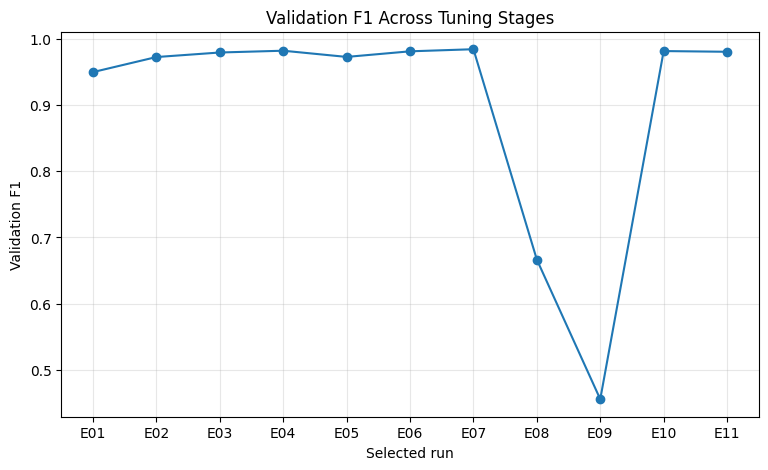

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(tuning_df['Selected Run'] if 'Selected Run' in tuning_df.columns else tuning_df['Run ID'], tuning_df['Val F1'], marker='o')
plt.xlabel('Selected run')
plt.ylabel('Validation F1')
plt.title('Validation F1 Across Tuning Stages')
plt.grid(True, alpha=0.3)
plt.show()

## Final evaluation results

These are the saved evaluation metrics from the final selected checkpoint on the held-out test split and two external unseen datasets.

In [5]:
evaluation_data = [
    {'Evaluation Set': 'Held-out Test Split', 'Dataset': 'Kaggle 140K test split', 'Checkpoint': 'E07_best.pth', 'Accuracy': 0.985700, 'Precision': 0.983187, 'Recall': 0.988300, 'F1': 0.985737, 'ROC-AUC': 0.998883, 'Loss': 0.040551},
    {'Evaluation Set': 'Unseen Dataset A', 'Dataset': '130K Real vs Fake Face', 'Checkpoint': 'E07_best.pth', 'Accuracy': 0.520106, 'Precision': 0.522188, 'Recall': 0.991971, 'F1': 0.684202, 'ROC-AUC': 0.406541, 'Loss': 3.733826},
    {'Evaluation Set': 'Unseen Dataset B', 'Dataset': 'Deepfake-vs-Real', 'Checkpoint': 'E07_best.pth', 'Accuracy': 0.483875, 'Precision': 0.491793, 'Recall': 0.966250, 'F1': 0.651826, 'ROC-AUC': 0.306554, 'Loss': 3.926518},
]
evaluation_df = pd.DataFrame(evaluation_data)
evaluation_df

,Evaluation Set,Dataset,Checkpoint,Accuracy,Precision,Recall,F1,ROC-AUC,Loss
0,Held-out Test Split,Kaggle 140K test split,E07_best.pth,0.985700,0.983187,0.988300,0.985737,0.998883,0.040551
1,Unseen Dataset A,130K Real vs Fake Face,E07_best.pth,0.520106,0.522188,0.991971,0.684202,0.406541,3.733826
2,Unseen Dataset B,Deepfake-vs-Real,E07_best.pth,0.483875,0.491793,0.966250,0.651826,0.306554,3.926518


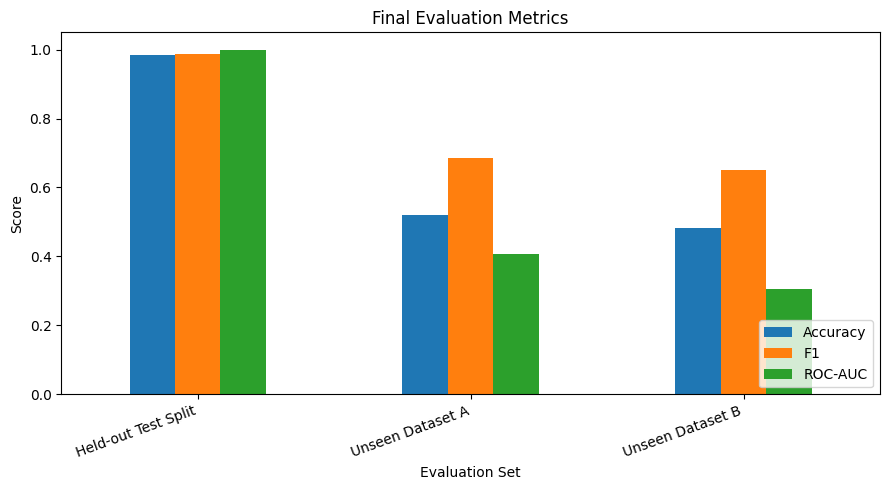

In [6]:
metrics = ['Accuracy', 'F1', 'ROC-AUC']
ax = evaluation_df.set_index('Evaluation Set')[metrics].plot(kind='bar', figsize=(9, 5))
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Final Evaluation Metrics')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

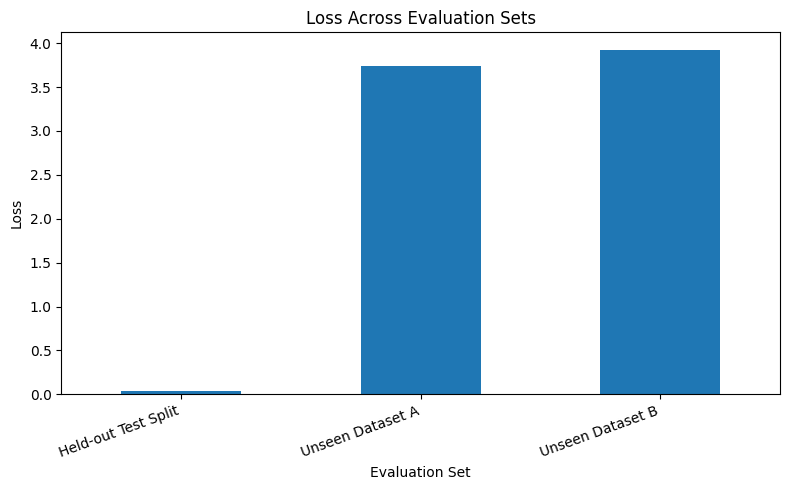

In [7]:
ax = evaluation_df.set_index('Evaluation Set')['Loss'].plot(kind='bar', figsize=(8, 5))
plt.ylabel('Loss')
plt.title('Loss Across Evaluation Sets')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Optional: loading saved result files

The notebook currently uses embedded results so it works in GitHub even if a grader does not have your local files. If you export CSVs into `results/`, use the pattern below to load them.

In [8]:
def load_results_csv(filename, fallback_df):
    path = RESULTS_DIR / filename
    if path.exists():
        print(f'Loaded {path}')
        return pd.read_csv(path)
    print(f'{path} not found; using embedded results.')
    return fallback_df.copy()

# Example:
# evaluation_df = load_results_csv('MODEL_final_evaluation.csv', evaluation_df)

## Final interpretation

The final selected EfficientNet-B3 run was **E07**, which used AdamW, learning rate `3e-4`, weight decay `1e-3`, light augmentation, batch size `8`, and no scheduler. E07 produced the best validation result among the EfficientNet-B3 tuning runs, with validation F1 of approximately **0.9840**. On the held-out in-domain test split, it achieved test F1 of approximately **0.9857** and ROC-AUC of approximately **0.9989**.

As with ResNet-50, EfficientNet-B3 performed much better on the in-domain test split than on the unseen external datasets. This suggests that the final model learned the original dataset distribution well but struggled when evaluated on data from different sources.

## Files to include in GitHub

- Final notebook: this notebook
- Experiment notebook: `EfficientNet-B3_exp-REDO.ipynb`
- Reproducibility notebook: `EfficientNet_B3_reproduce_updated.ipynb`
- Dataset link or instructions in `README.md`
- Checkpoint link or instructions in `checkpoints/README.md` if the `.pth` file is too large for GitHub